# Week4 - Lab Rupesh_koram_dz93614

Take a look at these toy datasets. Perform the following operations
* Train-test split
* Train a linear regression model
* Evaluate/create residual plots
* Explain findings

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

data1 = pd.read_csv('https://raw.githubusercontent.com/msaricaumbc/DS_data/master/ds602/regression/lab4_1.csv', index_col=0)
#data2 = pd.read_csv('https://raw.githubusercontent.com/msaricaumbc/DS_data/master/ds602/regression/lab4_2.csv', index_col=0)

In [31]:
data1.head()

,X,y
0,50,147
1,82,246
2,66,207
3,35,105
4,81,240


In [32]:
data1.isnull().sum()

X    0
y    0
dtype: int64

In [33]:
X = np.array(data1['X']).reshape(-1,1)
y = np.array(data1['y']).reshape(-1,1)

X.shape, y.shape

((100, 1), (100, 1))

In [34]:
from sklearn.model_selection import train_test_split

X_training, X_test, y_training, y_test = train_test_split(X, y, test_size=0.20)

print(f'Training samples: {X_training.shape[0]:,}')
print(f'Test samples: {X_test.shape[0]:,}')


Training samples: 80
Test samples: 20


In [35]:
import statsmodels.api as smf

simpleModel = smf.OLS(X_training, y_training).fit()
print(simpleModel.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.997
Model:                            OLS   Adj. R-squared (uncentered):              0.997
Method:                 Least Squares   F-statistic:                          2.776e+04
Date:                Tue, 26 Sep 2023   Prob (F-statistic):                   2.21e-102
Time:                        22:48:19   Log-Likelihood:                         -197.74
No. Observations:                  80   AIC:                                      397.5
Df Residuals:                      79   BIC:                                      399.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [36]:
import statsmodels.api as smf

simpleModel = smf.OLS(X_test, y_test).fit()

print(simpleModel.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.999
Model:                            OLS   Adj. R-squared (uncentered):              0.999
Method:                 Least Squares   F-statistic:                          1.405e+04
Date:                Tue, 26 Sep 2023   Prob (F-statistic):                    9.96e-29
Time:                        22:48:20   Log-Likelihood:                         -42.943
No. Observations:                  20   AIC:                                      87.89
Df Residuals:                      19   BIC:                                      88.88
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

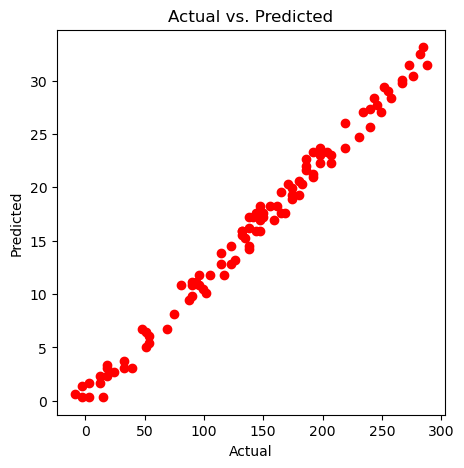

array([[130.09910144, 119.28252635, 124.6908139 , ..., 128.07099361,
        130.09910144, 129.08504752],
       [229.09910144, 218.28252635, 223.6908139 , ..., 227.07099361,
        229.09910144, 228.08504752],
       [190.09910144, 179.28252635, 184.6908139 , ..., 188.07099361,
        190.09910144, 189.08504752],
       ...,
       [157.09910144, 146.28252635, 151.6908139 , ..., 155.07099361,
        157.09910144, 156.08504752],
       [142.09910144, 131.28252635, 136.6908139 , ..., 140.07099361,
        142.09910144, 141.08504752],
       [130.09910144, 119.28252635, 124.6908139 , ..., 128.07099361,
        130.09910144, 129.08504752]])

In [37]:
yhat = simpleModel.predict(X)

resid = y - yhat

plt.figure(figsize=(5,5))
plt.plot(y, yhat, 'ro')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs. Predicted')
plt.show()

resid

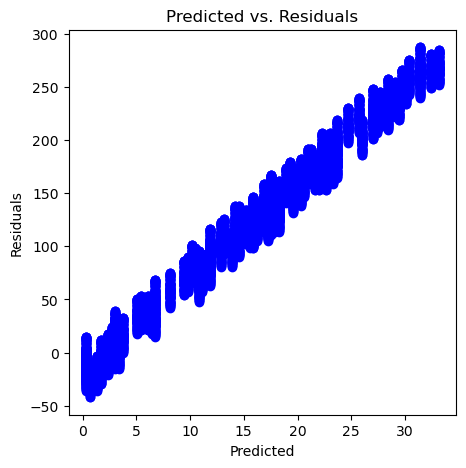

In [38]:
plt.figure(figsize=(5,5))
plt.plot(yhat, resid, 'bo')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Predicted vs. Residuals')
plt.show()

In [39]:
simpleModel.rsquared

0.9986490679488925

In [40]:
# DATA 2

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

#data1 = pd.read_csv('https://raw.githubusercontent.com/msaricaumbc/DS_data/master/ds602/regression/lab4_1.csv', index_col=0)
data2 = pd.read_csv('https://raw.githubusercontent.com/msaricaumbc/DS_data/master/ds602/regression/lab4_2.csv', index_col=0)

In [42]:
data2.head()

,X1,X2,y
0,50,B,2510
1,82,B,6738
2,66,B,4355
3,35,A,2225
4,81,A,7560


In [43]:
data2.isnull().sum()

X1    0
X2    0
y     0
dtype: int64

In [44]:
data2['X2'].unique()

array(['B', 'A'], dtype=object)

In [45]:
# create dummies for X2 Column

dummies = pd.get_dummies(data2['X2'], prefix='X2')

# Concatenate the dummy variables with the original DataFrame
data2 = pd.concat([data2, dummies], axis=1)

# Drop the original 'X2' column if needed
data2 = data2.drop('X2', axis=1)

# Now, dataframe contains the dummy variables
print(data2)


    X1     y  X2_A  X2_B
0   50  2510     0     1
1   82  6738     0     1
2   66  4355     0     1
3   35  2225     1     0
4   81  7560     1     0
..  ..   ...   ...   ...
95  98  9615     0     1
96   9  1066     1     0
97  56  4139     1     0
98  50  2502     0     1
99  53  3815     1     0

[100 rows x 4 columns]


In [46]:
y = data2.y

features = ['X1','X2_A','X2_B']
X = data2[features]

X.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      100 non-null    int64
 1   X2_A    100 non-null    uint8
 2   X2_B    100 non-null    uint8
dtypes: int64(1), uint8(2)
memory usage: 1.8 KB


In [47]:
from sklearn.model_selection import train_test_split

X_training, X_test, y_training, y_test = train_test_split(X, y, test_size=0.20)

print(f'Training samples: {X_training.shape[0]:,}')
print(f'Test samples: {X_test.shape[0]:,}')

Training samples: 80
Test samples: 20


In [48]:
X_training.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 80 entries, 70 to 90
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      80 non-null     int64
 1   X2_A    80 non-null     uint8
 2   X2_B    80 non-null     uint8
dtypes: int64(1), uint8(2)
memory usage: 1.4 KB


In [49]:
from sklearn.linear_model import LinearRegression

In [50]:
model = LinearRegression()
model.fit(X_training,y_training)

LinearRegression()

In [51]:
y_predictions = model.predict(X_test)

In [52]:
y_predictions

array([7414.15637059, 2830.67835717, 3280.03894672, 2659.70296701,
       1572.46870642, 6155.94671985, 2830.67835717, 3459.78318254,
       6964.79578104, 3100.2947109 , 4007.78473566, 1392.7244706 ,
       1123.10811687, 5167.35342283, 3729.39953627,  502.77213716,
       2381.31776762, 3999.01589   , 3280.03894672, 4636.88956103])

In [53]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_predictions)
mse

687145.9926004445

In [54]:
rmse = np.sqrt(mse)
rmse

828.9426956071478

In [55]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_predictions)
r2

0.881935293979077

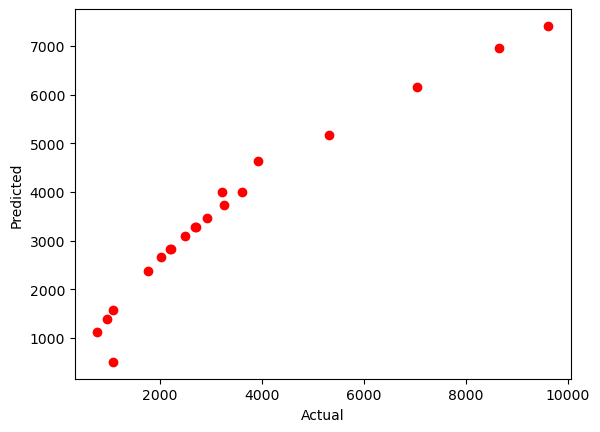

In [56]:
import matplotlib.pyplot as plt

plt.plot(y_test, y_predictions, 'ro')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

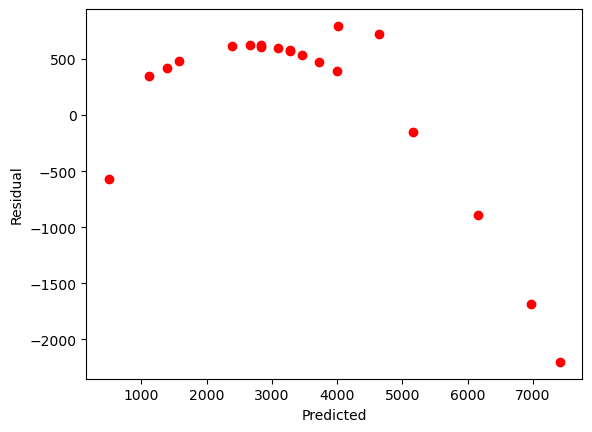

In [57]:
plt.plot(y_predictions, y_predictions - y_test, 'ro')
plt.ylabel('Residual')
plt.xlabel('Predicted')
plt.show()